# Lesson 2: Tool Calling
Ref: [deeplearning.ai](https://learn.deeplearning.ai/courses/building-agentic-rag-with-llamaindex/lesson/ix5w5/building-an-agent-reasoning-loop)     
Login with email: ashok@fsm.ac.in (password is the usual one)    
   
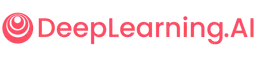

## Setup

In [63]:
# 1.0 Needed for nested parallel I/O processing
import nest_asyncio
nest_asyncio.apply()

## Most important

1. Even smaller models, such as: llama3.2:1b, may be able to answer your questions if tool descriptions are proper. So pay attention to tool descriptions.
2. LocalAI models have problems loading.

## Conceptual questions and answers

Q1: How is function calling different from tool calling?

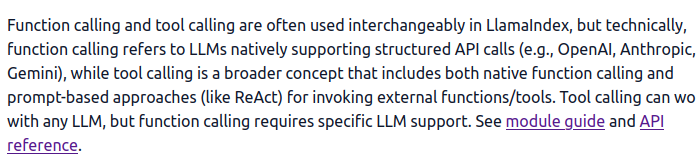

Q2: In the sentence " tool calling is a broader concept that includes both native function calling and prompt-based approaches" what is meant by prompt based approaches

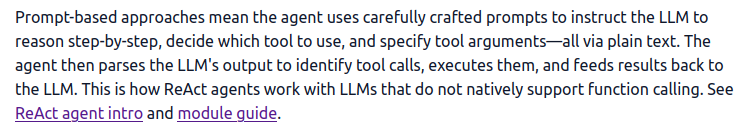

Q3: And what is meant by natively supporting function calling

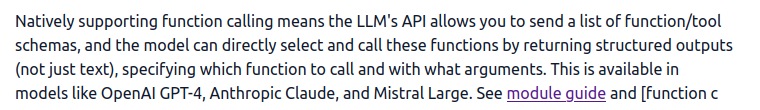

Q4: When you say 'agent uses carefully crafted prompts to instruct the LLM to reason step-by-step, ', which LLM you are talking about. As I understand Agent itself has an LLM and are you referring to a different LLM

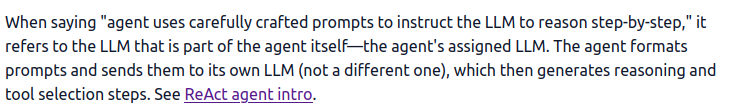

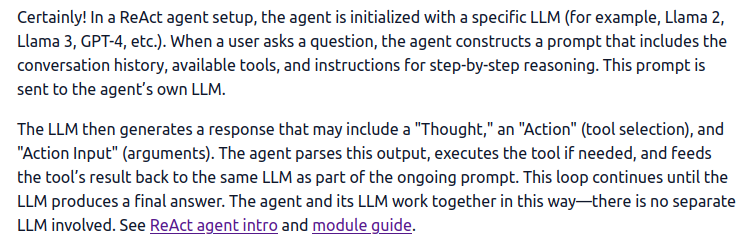

Q5: Would it be possible for you to give simple example of "agent constructs a prompt that includes the conversation history, available tools, and instructions for step-by-step reasoning. "

Yes here is the answer:

>*You are designed to help with a variety of tasks, from answering questions to providing summaries to other types of analyses.*

>### *Tools*

>>*You have access to the following tools:*
*add: Add two numbers.*
*multiply: Multiply two numbers.*

>### *Output Format*

>>*Please answer in the same language as the question and use the following format:*

>>*Thought: The current language of the user is: English. I need to use a tool to help me answer the question.*
*Action: tool name (one of add, multiply) if using a tool.*
*Action Input: the input to the tool, in a JSON format representing the kwargs (e.g. ("a": 2, "b": 3))*

>>*Please ALWAYS start with a Thought.*

>### *Current Conversation*

>>*user: What is 2 + 3?*


Q6: What would be a example for LLMs that natively support function calling?

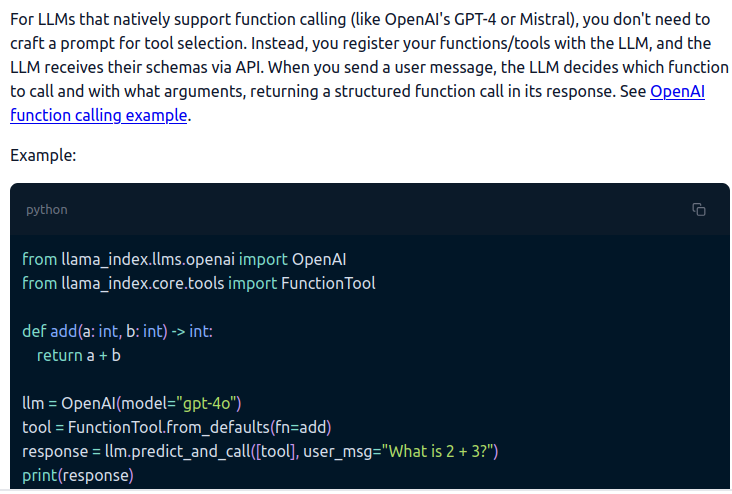

>Here, the LLM receives the tool schema and user message, and natively returns a function call with arguments, which the agent executes.

## 1. Define a Simple Tool

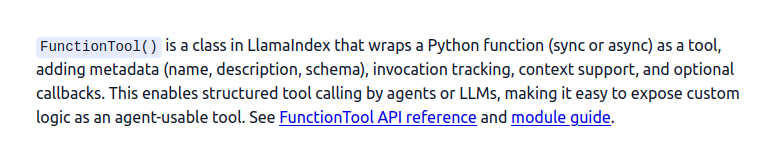

>FunctionTool is a subclass of AsyncBaseTool (which inherits from BaseTool), so it transforms a Python function into a BaseTool-compatible object with added metadata and agent/LLM integration features

In [77]:
# 2.0
from llama_index.core.tools import FunctionTool

# Define functions.
# Note that comments within functions are important

# 2.1
def add(x: int, y: int) -> int:
    """Adds two integers together."""
    return x + y

# 2.2
def mystery(x: str, y: str) -> int: 
    """Mystery function that operates on top of two numbers."""
    x = int(x)
    y = int(y)
    return (x + y) * (x + y)


# 2.3 Transform functions to tools of llamaindex
#      Generally we should mention, name and description also 
add_tool = FunctionTool.from_defaults(fn=add)   # Incomplete

mystery_tool = FunctionTool.from_defaults(fn=mystery,
                                          name = "mystery",
                                          description="Operations other than adding two integers."
                                         )

# 2.4 Could have been done as follows also:
add_tool = FunctionTool.from_defaults(fn=add,
                                      name="add",
                                      description="Adds two integers together."
                                     )

# 2.5 add_tool() can be used either by
#      an agent or called directly
result = add_tool(3, 4)
print(result)  

7


### Predict and call the tool.
`predict_and_call()` by default uses a `ReAct` agent to do tool calling (through text prompting), but function calling LLMs will implement this differently. It is an `async` function. It can take chat message/history as well.   
Full syntax:    
>apredict_and_call(tools: List[BaseTool], user_msg: Optional[Union[str, ChatMessage]] = None, chat_history: Optional[List[ChatMessage]] = None, verbose: bool = False, **kwargs: Any) -> AgentChatResponse

## What is a ReAct agent    

A "ReACT agent" (short for Reasoning and Acting) is a framework that empowers Large Language Models (LLMs) to solve complex tasks by combining natural language reasoning with the ability to take actions, such as accessing and using tools. 
Here's a more detailed breakdown: 

>    **Reasoning and Acting:**     
    >>ReACT agents alternate between thinking (reasoning) and acting (executing tasks).     

>    **LLM Enhancement:**     
    >>ReACT enhances LLMs by allowing them to not only understand and process information but also take concrete steps based on their understanding.     

>    **Dynamic and Step-by-Step:**         
>>    ReACT agents employ a dynamic, step-by-step approach, starting with a thought, taking an action, and using the result to refine reasoning and decide on the next action.     

>    **Tool Usage:**     
>>    ReACT agents can utilize various tools to interact with external sources (search engines, databases, knowledge bases, etc.) to gather new information and refine their responses.     

>    **Example:**     
>>    Imagine a ReACT agent tasked with finding the tallest building in Bengaluru. It might first reason about the need to search for information, then use a search tool to find relevant data, and finally, use that data to determine the tallest building.     

The reasoning and action agent, abbreviated as the ReACT agent, is a framework that incorporates the reasoning capabilities of LLMs with the ability to take actionable steps. This means they can not only understand and process information but also take concrete steps based on their understanding. These agents can comprehend and process information, assess situations, take apt actions, communicate responses and track ongoing situations. They are, thus, designed to interact with the real world through actions, such as searching the web, accessing databases, or controlling physical devices while leveraging the language abilities of LLMs for planning, decision-making, and knowledge acquisition. (Ref: See [here](https://www.leewayhertz.com/react-agents-vs-function-calling-agents/))

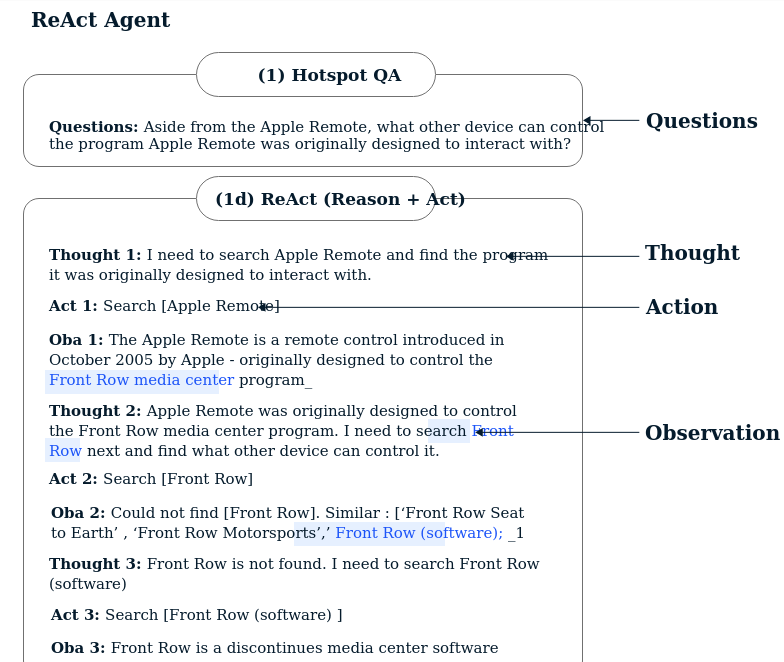

## How do ReACT agents work?

Unlike traditional AI systems that separate decision-making from execution, ReACT agents follow a continuous loop of reasoning and action. Here’s how ReACT agents work:

>    **Input**: An agent receives a task description in natural language, which is fed into the core LLM.

>    **Reasoning**: The LLM breaks down the task into smaller steps, analyzes the situation, considers available information and plans the actions required to complete it.

>    **Action**: Based on the reasoning, the LLM decides which tool to use (e.g., search engine, database, API) and executes actions to gather information or interact with the external environment. This might involve querying Wikipedia for relevant facts or retrieving data from a company database.     

>    **Observation**: The agent observes the results of the actions and updates its knowledge accordingly. The agent also uses this new information to refine its reasoning in the next iteration.


>    Response: The agent generates a final response based on reasoning and the information gathered.     


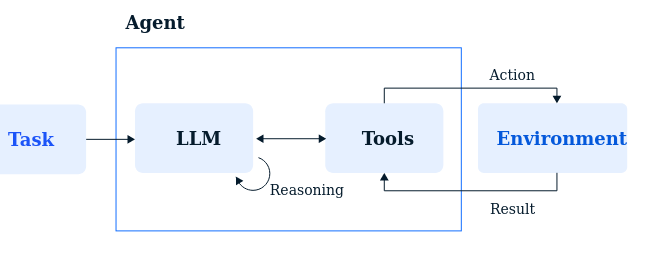

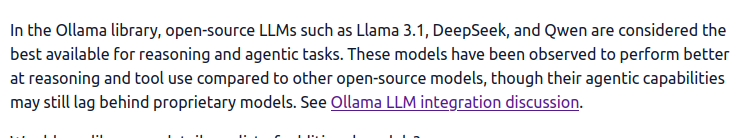

In [78]:
%%time

# Using LocalAI
# Avoid using it

# 3.0
from llama_index.embeddings.ollama import OllamaEmbedding
from llama_index.llms.openai_like import OpenAILike

# 3.1 Very small model. May sometimes work. Use the model in the next cell
llm = OpenAILike(
                  temperature=0.7,
                  model= "smolvlm-500m-instruct" , # "gpt-3.5-turbo", #   "nanbeige4.1-3b-q4",   #         "gpt-3.5-turbo",                      # Can be any name, not necessarily openai's gpt
                  api_base="http://127.0.0.1:8080/v1",
                  api_key="fake",
                  timeout= 120.0,
                  is_chat_model = True,
                  is_function_calling_model=True,
                  )


CPU times: user 75 μs, sys: 4 μs, total: 79 μs
Wall time: 80.3 μs


In [80]:
# Using Ollama

# 3.0 Call libraries
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.ollama import OllamaEmbedding

# 3.1 Configure the model
llm = Ollama(model="llama3.2:1b",    # Note it is 1b model
             request_timeout=120.0,
             temperature = 0.9
            )


In [81]:
# 3.2 Predict which tool to use and then call it
#     Can take chatmessage also:

response = llm.predict_and_call(
                                [add_tool, mystery_tool], 
                                "Tell me the output of the mystery function on 2 and 9", 
                                verbose=True
                               )

# 3.3
print(str(response))

2026-04-15 13:34:57,565 - INFO - HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
2026-04-15 13:34:58,565 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


=== Calling Function ===
Calling function: mystery with args: {"x": "2", "y": "9"}
=== Function Output ===
121
121


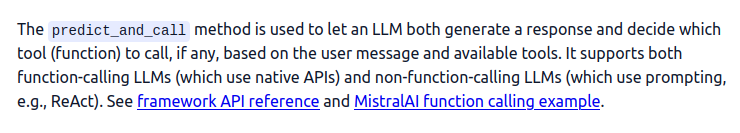

**Demo for Function-calling LLM example (OpenAI, Mistral, Bedrock, etc.):**

In [100]:
# 3.4 Call libraries
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.ollama import OllamaEmbedding
from llama_index.core.tools import FunctionTool

# 3.5 Configure the model
llm = Ollama(model="llama3.2:latest",    # Note it is 1b model
             request_timeout=120.0,
             temperature = 0.9
            )

# 3.6
def add(a: int, b: int) -> int:
    return a + b

# 3.7
tool = FunctionTool.from_defaults(fn=add)
response = llm.predict_and_call([tool],
                                user_msg="What is 2 + 3?",
                                verbose = True
                               )

# 3.7.1
print(response)

"""
Note these:

    === Calling Function ===
    Calling function: add with args: {"b": 3, "a": 2}
    === Function Output ===

"""


2026-04-15 14:39:50,374 - INFO - HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
2026-04-15 14:39:51,170 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


=== Calling Function ===
Calling function: add with args: {"b": 3, "a": 2}
=== Function Output ===
5
5


**Non-function-calling LLM example (prompt-based, e.g., ReAct with Llama 2, Llama 3, etc.):**

In [11]:
# 3.8 Call libraries
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.ollama import OllamaEmbedding
from llama_index.core.tools import FunctionTool
from llama_index.core.agent import ReActAgent

# 3.9 Configure the model
llm = Ollama(model="llama2",    
             request_timeout=120.0,
             temperature = 0.9

            )

# 3.10
def add(a: int, b: int) -> int:
    return a + b

# 3.11
tool = FunctionTool.from_defaults(fn=add)

# 3.12
#agent = ReActAgent.from_tools([tool], llm=llm, verbose=True)
agent = ReActAgent(tools=[add], llm=llm, verbose = True)


# 3.13
response = agent.run("What is 2 + 3?")
print(response)



WorkflowHandler(workflow=llama_index.core.agent.workflow.react_agent.ReActAgent, run_id=dUp2csQDFD, result=None)
[tick] add: AgentWorkflowStartEvent(user_msg='What is 2 + 3?', chat_history=None, memory=None, max_iterations=None, early_stopping_method=None)
[init_run:0] started from AgentWorkflowStartEvent
[init_run:0] complete with AgentInput
[tick] add: AgentInput(input=[ChatMessage(role=<MessageRole.USER: 'user'>, additional_kwargs={}, blocks=[TextBlock(block_type='text', text='What is 2 + 3?')])], current_agent_name='Agent')
[setup_agent:0] started from AgentInput
[setup_agent:0] complete with AgentSetup
[tick] add: AgentSetup(input=[ChatMessage(role=<MessageRole.USER: 'user'>, additional_kwargs={}, blocks=[TextBlock(block_type='text', text='What is 2 + 3?')])], current_agent_name='Agent')
[run_agent_step:0] started from AgentSetup
[run_agent_step:0] complete with AgentOutput
[tick] add: AgentOutput(response=ChatMessage(role=<MessageRole.ASSISTANT: 'assistant'>, additional_kwargs={}

2026-04-15 12:52:27,786 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


[run_agent_step:0] complete with AgentOutput
[tick] add: AgentOutput(response=ChatMessage(role=<MessageRole.ASSISTANT: 'assistant'>, additional_kwargs={}, blocks=[TextBlock(block_type='text', text='Thought: I apologize for the mistakes, let me try to ans...
[parse_agent_output:0] started from AgentOutput
[result] StopEvent(result=AgentOutput(response=ChatMessage(role=<MessageRole.ASSISTANT: 'assistant'>, additional_kwargs={}, blocks=[TextBlock(block_type='text', text='5')]), structured_response=None, curren...
[parse_agent_output:0] complete with StopEvent


#### Using RouterQueryEngine

Can we use RouterQueryEngine: No.     
Router engine will not work with FunctionTool

<b>ToDo:</b>  Check if RouterQueryEngine can have chat nethod

In [9]:
# Router engine does not work with FunctionTool object
# 3.14
from llama_index.core.query_engine.router_query_engine import RouterQueryEngine
from llama_index.core.selectors import LLMSingleSelector
from llama_index.core import Settings

Settings.llm = llm
# 3.15
# Router takes two arguments:
#                              Which router
#                              NAmes of Query engine tools

query_engine = RouterQueryEngine(
                                 selector=LLMSingleSelector.from_defaults(),
                                 query_engine_tools=[
                                                        add_tool,        # FunctionTool do not work. Error comes
                                                        mystery_tool,    # FunctionTool do not work. Error comes
                                                    ],
                                 verbose=True
                               )
# 3.16
response = query_engine.query("Tell me the output of the mystery function on 2 and 9")
print(str(response))

AttributeError: 'FunctionTool' object has no attribute 'query_engine'

**ReAct Agent vs predict_and_call()**

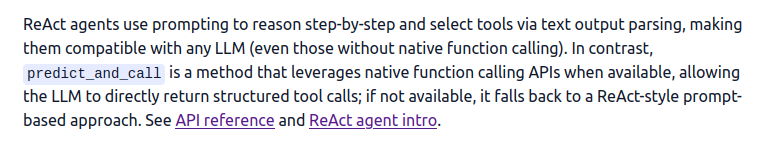

## 2. Define an Auto-Retrieval Tool

### Load Data

To download this paper, below is the needed code:

#!wget "https://openreview.net/pdf?id=VtmBAGCN7o" -O metagpt.pdf

**Note**: The pdf file is included with this lesson. To access it, go to the `File` menu and select`Open...`.

In [19]:
# 4.0
from llama_index.core import Settings

## Uses LocalAI. Does Not work

# 4.1
Settings.llm = OpenAILike(
                          temperature=0.7,
                          model=  "smolvlm-500m-instruct", #  "gpt-3.5-turbo",                      # Can be any name, not necessarily openai's gpt
                          api_base="http://127.0.0.1:8080/v1",
                          api_key="fake",
                          timeout= 120.0,
                          is_chat_model = True,
                          is_function_calling_model=True,
                          )


# 4.2
Settings.embed_model = OllamaEmbedding(
                                        model_name="nomic-embed-text",      # Using foundational model may be overkill
                                        base_url="http://localhost:11434",
                                       )

In [79]:
# Using Ollama

# 4.0 Call libraries
from llama_index.llms.ollama import Ollama
from llama_index.core import Settings
from llama_index.embeddings.ollama import OllamaEmbedding

# 4.1 Configure the model
llm = Ollama(model=  "llama3.2:1b",     # "qwen3.5:0.8b",      #      "qwen2.5:latest",    #
             request_timeout=1200.0,
             temperature = 0.9
            )

Settings.llm = llm




In [83]:
# 4.2
Settings.embed_model = OllamaEmbedding(
                                        model_name="nomic-embed-text",      # Using foundational model may be overkill
                                        base_url="http://localhost:11434",
                                       )

In [84]:
# 5.0
from llama_index.core import SimpleDirectoryReader

path = "/home/ashok/Documents/llamaindex/deeplearning_course/"

# 5.1 load documents
documents = SimpleDirectoryReader(
                                  input_files=[path + "metagpt.pdf"]     # List of input files
                                 ).load_data()

In [85]:
# 6.0
from llama_index.core.node_parser import SentenceSplitter

# 6.1 splitter or parser (sme thing)
splitter = SentenceSplitter(chunk_size=1024)

# 6.2 Split parsed document into chunks (nodes)
nodes = splitter.get_nodes_from_documents(documents)

In [86]:
# 6.3
print(nodes[0].get_content(metadata_mode="all"))

page_label: 1
file_name: metagpt.pdf
file_path: /home/ashok/Documents/llamaindex/deeplearning_course/metagpt.pdf
file_type: application/pdf
file_size: 16911937
creation_date: 2026-04-13
last_modified_date: 2026-04-13

Preprint
METAGPT: M ETA PROGRAMMING FOR A
MULTI-AGENT COLLABORATIVE FRAMEWORK
Sirui Hong1∗, Mingchen Zhuge2∗, Jonathan Chen1, Xiawu Zheng3, Yuheng Cheng4,
Ceyao Zhang4, Jinlin Wang1, Zili Wang, Steven Ka Shing Yau5, Zijuan Lin4,
Liyang Zhou6, Chenyu Ran1, Lingfeng Xiao1,7, Chenglin Wu1†, J¨urgen Schmidhuber2,8
1DeepWisdom, 2AI Initiative, King Abdullah University of Science and Technology,
3Xiamen University, 4The Chinese University of Hong Kong, Shenzhen,
5Nanjing University, 6University of Pennsylvania,
7University of California, Berkeley, 8The Swiss AI Lab IDSIA/USI/SUPSI
ABSTRACT
Remarkable progress has been made on automated problem solving through so-
cieties of agents based on large language models (LLMs). Existing LLM-based
multi-agent systems can already solve si

In [87]:
# 7.0
from llama_index.core import VectorStoreIndex

# 7.1
vector_index = VectorStoreIndex(nodes, show_progress = True)
query_engine = vector_index.as_query_engine(similarity_top_k=2)

Generating embeddings: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [00:16<00:00,  2.03it/s]


In [88]:
%%time

# 8.0
from llama_index.core.vector_stores import MetadataFilters

# 8.1
query_engine = vector_index.as_query_engine(
                                            similarity_top_k=2,
                                            filters=MetadataFilters.from_dicts(
                                                                                [
                                                                                    {"key": "page_label", "value": "2"}
                                                                                ]
                                                                              )
                                            )

# 8.2
response = query_engine.query(
                                "What are some high-level results of MetaGPT paper?", 
                             )

2026-04-15 13:37:41,244 - INFO - HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-04-15 13:37:53,175 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


CPU times: user 8.3 ms, sys: 64 μs, total: 8.37 ms
Wall time: 12 s


In [89]:
print(str(response))

MetaGPT achieves a new state-of-the-art in code generation benchmarks, outperforming other popular frameworks. Specifically, it reaches 85.9% and 87.7% Pass@1 scores in two publicly available evaluations. Furthermore, MetaGPT demonstrates robustness and efficiency by achieving a 100% task completion rate in experimental evaluations.


In [90]:
for n in response.source_nodes:
    print(n.metadata)

{'page_label': '2', 'file_name': 'metagpt.pdf', 'file_path': '/home/ashok/Documents/llamaindex/deeplearning_course/metagpt.pdf', 'file_type': 'application/pdf', 'file_size': 16911937, 'creation_date': '2026-04-13', 'last_modified_date': '2026-04-13'}


### Define the Auto-Retrieval Tool

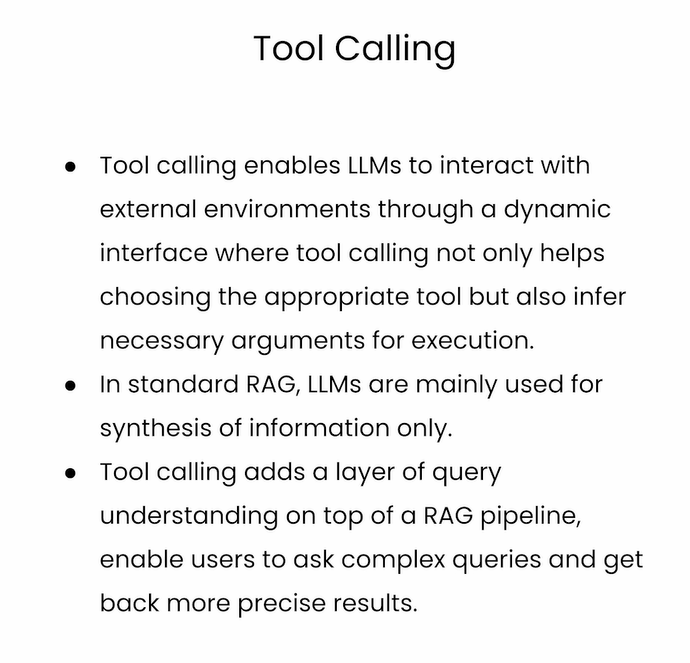

In [101]:
# 9.0
from typing import List
from llama_index.core.vector_stores import FilterCondition

# 9.1
def vector_query(
                 query: str, 
                 page_numbers: List[str]
                ) -> str:
    
    """Perform a vector search over an index.
    
    query (str): the string query to be embedded.
    page_numbers (List[str]): Filter by set of pages. Leave BLANK if we want to perform a vector search
        over all pages. Otherwise, filter by the set of specified pages.
    
    """

    # 9.2    
    metadata_dicts = [
                       {"key": "page_label", "value": p} for p in page_numbers
                     ]
    
    # 9.3
    query_engine = vector_index.as_query_engine(
                                                similarity_top_k=2,
                                                filters=MetadataFilters.from_dicts(
                                                                                    metadata_dicts,
                                                                                     condition=FilterCondition.OR
                                                                                     )
     # 9.4                                            )
    response = query_engine.query(query)
    return response
    



In [92]:
# 10.0
vector_query_tool = FunctionTool.from_defaults(
                                                name="vector_tool",
                                                fn=vector_query,
                                                description=(
                                                    "Useful if you want to extract any information from MetaGPT other than its summary."
                                                )
                                               )

In [93]:
%%time

# 10.1
llm = Settings.llm

# 10.2
response = llm.predict_and_call(
                                [vector_query_tool], 
                               "What are the high-level results of MetaGPT as described on page 2?", 
                                verbose=True
                               )

2026-04-15 13:38:23,452 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


=== Calling Function ===
Calling function: vector_tool with args: {"query": "high-level results of MetaGPT as described on page 2", "page_numbers": "[2]"}


2026-04-15 13:38:24,502 - INFO - HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-04-15 13:38:35,869 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


=== Function Output ===
MetaGPT achieves a new state-of-the-art in code generation benchmarks. Specifically, it shows remarkable performance with Pass@1 scores of 85.9% and 87.7%. Additionally, MetaGPT demonstrates exceptional robustness and efficiency by achieving a 100% task completion rate in experimental evaluations.
CPU times: user 19 ms, sys: 4.01 ms, total: 23 ms
Wall time: 14.9 s


In [94]:
# 10.3
for n in response.source_nodes:
    print(n.metadata)

{'page_label': '2', 'file_name': 'metagpt.pdf', 'file_path': '/home/ashok/Documents/llamaindex/deeplearning_course/metagpt.pdf', 'file_type': 'application/pdf', 'file_size': 16911937, 'creation_date': '2026-04-13', 'last_modified_date': '2026-04-13'}


## Let's add some other tools!

In [95]:
# 11.0
from llama_index.core import SummaryIndex
from llama_index.core.tools import QueryEngineTool

# 11.1
summary_index = SummaryIndex(nodes)

# 11.2
summary_query_engine = summary_index.as_query_engine(
                                                    response_mode="tree_summarize",
                                                    use_async=True,
                                                    )

# 11.3
summary_tool = QueryEngineTool.from_defaults(
                                                name="summary_tool",
                                                query_engine=summary_query_engine,
                                                description=(
                                                    "Useful if you want to get a summary of the paper: MetaGPT"
                                                ),
                                            )

In [ ]:
# Try better LLMs

In [61]:
# 12.1 Configure the model
llm = Ollama(model= "llama3.2", #     "mistral:latest",      #      "qwen2.5:latest",    #
             request_timeout=1200.0,
             temperature = 0.9
            )

# 12.2
Settings.llm = llm


In [96]:
# 13.0 llm: llama3.2:1b NOT llama3.2:latest
response = llm.predict_and_call(
                                [vector_query_tool, summary_tool], 
                                "What are the MetaGPT comparisons with ChatDev described on page 8?", 
                                 verbose=True
                               )

2026-04-15 13:38:56,392 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


=== Calling Function ===
Calling function: vector_tool with args: {"query": "ChatDev vs MetaGPT on page 8", "page_numbers": "[\"8\"]"}


2026-04-15 13:38:57,411 - INFO - HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-04-15 13:39:07,890 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


=== Function Output ===
MetaGPT outperforms ChatDev on nearly all metrics in the SoftwareDev dataset, achieving higher scores in executability (3.75 vs 2.25) and productivity (124.3 vs 126.5), while taking significantly less time to generate code (503 seconds vs 762 seconds).


In [97]:
for n in response.source_nodes:
    print(n.metadata)

{'page_label': '8', 'file_name': 'metagpt.pdf', 'file_path': '/home/ashok/Documents/llamaindex/deeplearning_course/metagpt.pdf', 'file_type': 'application/pdf', 'file_size': 16911937, 'creation_date': '2026-04-13', 'last_modified_date': '2026-04-13'}


In [98]:
# 14.0 Takes very long time

response = llm.predict_and_call(
                                [vector_query_tool, summary_tool], 
                                "What is a summary of the paper?", 
                                 verbose=True
                               )

2026-04-15 13:39:18,747 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


=== Calling Function ===
Calling function: summary_tool with args: {"input": "MetaGPT"}


2026-04-15 13:43:34,493 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


=== Function Output ===
MetaGPT is a meta-programming framework for LLM-based multi-agent systems that leverages Standard Operating Procedures (SOPs) to enhance problem-solving capabilities. It models a group of agents as a simulated software company, utilizing role specialization, workflow management, and efficient sharing mechanisms such as message pools and subscriptions. MetaGPT achieves state-of-the-art performance on multiple benchmarks, particularly in code generation tasks, and offers a flexible and portable platform for autonomous agents and multi-agent frameworks.


In [ ]:
############### DONE #############